In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.shape

(891, 15)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [11]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [12]:
df.deck.unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F'], dtype=object)

In [13]:
df.embarked.unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [14]:
df.embark_town.unique()

array(['Southampton', 'Cherbourg', 'Queenstown', nan], dtype=object)

In [ ]:
# bu sekilde yaparsak eksik veri bulunan butun satirlari siler
# bu islem mantiksizdir cunku cok fazla veri kaybina neden olur
df.dropna()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [ ]:
# bu sekilde yaparsak eksik veri bulunan butun sutunlari siler
# bu islem "deck" sutunu icin mantiklidir cunku cok fazla eksik veri var
# 177 veri kaybi olan "age" sutunu icin tartisilabilir
# 2 veri kaybi olan "embarked" ve "embark_town" sutunlari icin de mantiksizdir
df.dropna(axis = 1)

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


In [ ]:
# imputation

In [19]:
# mean imputation

C:\Users\emresimsek\AppData\Local\Temp\ipykernel_13404\2153498542.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data = df, x = "age", palette = "muted", kde = True)


<Axes: xlabel='age', ylabel='Count'>

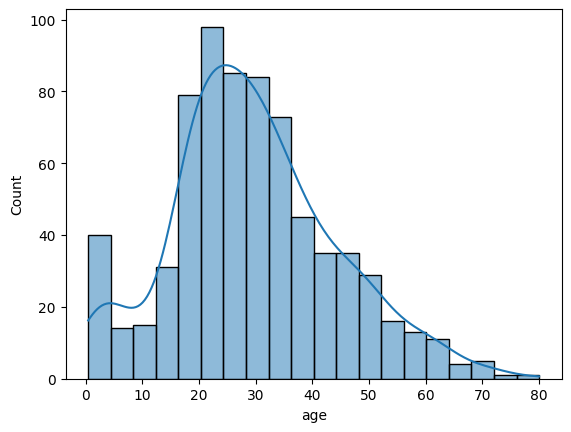

In [26]:
sns.histplot(data = df, x = "age", palette = "muted", kde = True)

In [ ]:
# veride cok fazla outlier yoksa mean imputation yapilabilir
# outlierlar fazla ise median imputation yapilabilir
df["age_mean"] = df["age"].fillna(df["age"].mean())

<Axes: xlabel='age_mean', ylabel='Count'>

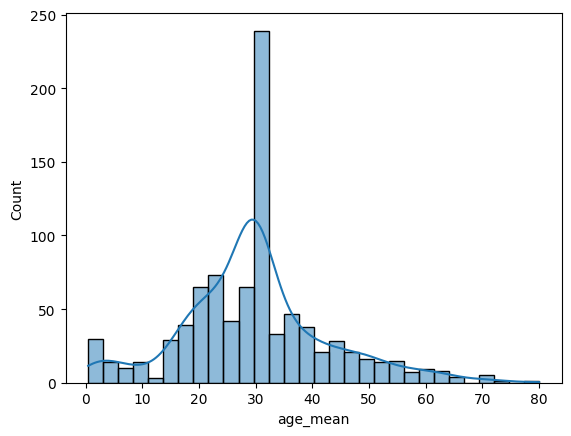

In [37]:
sns.histplot(data=df, x="age_mean", bins=30, kde=True)

In [28]:
df[["age_mean", "age"]]

,age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


<Axes: ylabel='age'>

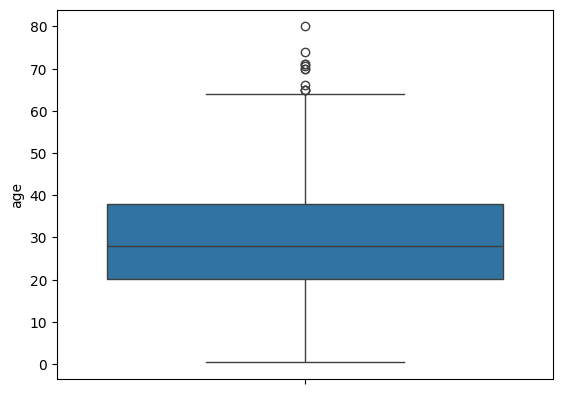

In [29]:
sns.boxplot(data = df, y = "age")

In [ ]:
# outlierlar fazla oldugundan median imputation yapalim

In [32]:
df["age"].median()

np.float64(28.0)

In [30]:
df["age_median"] = df["age"].fillna(df["age"].median())

<Axes: xlabel='age_median', ylabel='Count'>

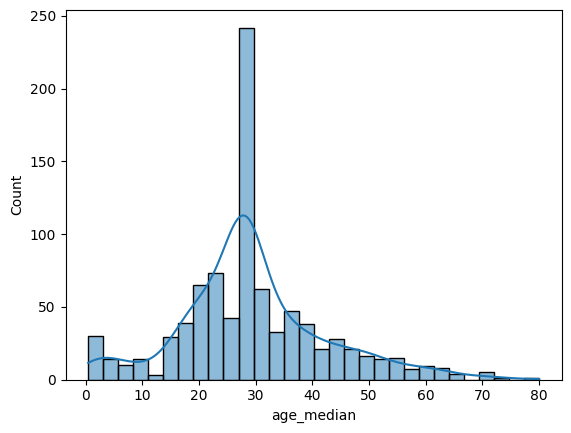

In [36]:
sns.histplot(data=df, x="age_median", bins=30, kde=True)

In [31]:
df[["age", "age_mean", "age_median"]]

,age,age_mean,age_median
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,NaN,29.699118,28.0
889,26.0,26.000000,26.0


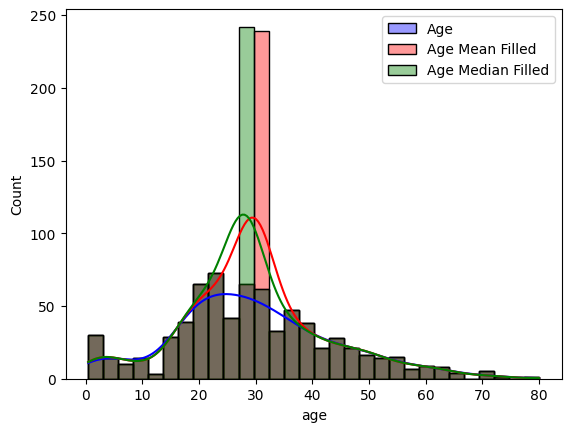

In [35]:
sns.histplot(df["age"], bins=30, color="blue", label="Age", kde=True, alpha=0.4)
sns.histplot(df["age_mean"], bins=30, color="red", label="Age Mean Filled", kde=True, alpha=0.4)
sns.histplot(df["age_median"], bins=30, color="green", label="Age Median Filled", kde=True, alpha=0.4)

plt.legend()
plt.show()

In [38]:
# mode imputation for categorical variables

In [39]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
age_mean         0
age_median       0
dtype: int64

In [ ]:
# 2 satirda eksik veri oldugundan dolayi isterek bu satirlari silebiliriz
df[df.embarked.isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [42]:
df.embarked.unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [51]:
# mode imputation
# kategorik degiskenlerde en cok tekrar eden degeri (mode) kullanarak eksik verileri doldurabiliriz
df.embarked.mode()[0]

'S'

In [50]:
embarked_mode_value = df[df.embarked.notna()]["embarked"].mode()[0]

In [59]:
df["embarked_mode"] = df["embarked"].fillna(embarked_mode_value)

In [74]:
df[["embarked", "embarked_mode"]].iloc[[61, 829]]

,embarked,embarked_mode
61,NaN,S
829,NaN,S


In [57]:
df["embarked"].isna().sum()

np.int64(2)

In [58]:
df["embarked_mode"].isna().sum()

np.int64(0)